<a href="https://colab.research.google.com/github/OJB-Quantum/Monte-Carlo-Sim/blob/main/Monte_Carlo_Sim_Fib_Fractal_Res_S21.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#1)
!pip install -q cupy-cuda12x matplotlib scipy gdstk

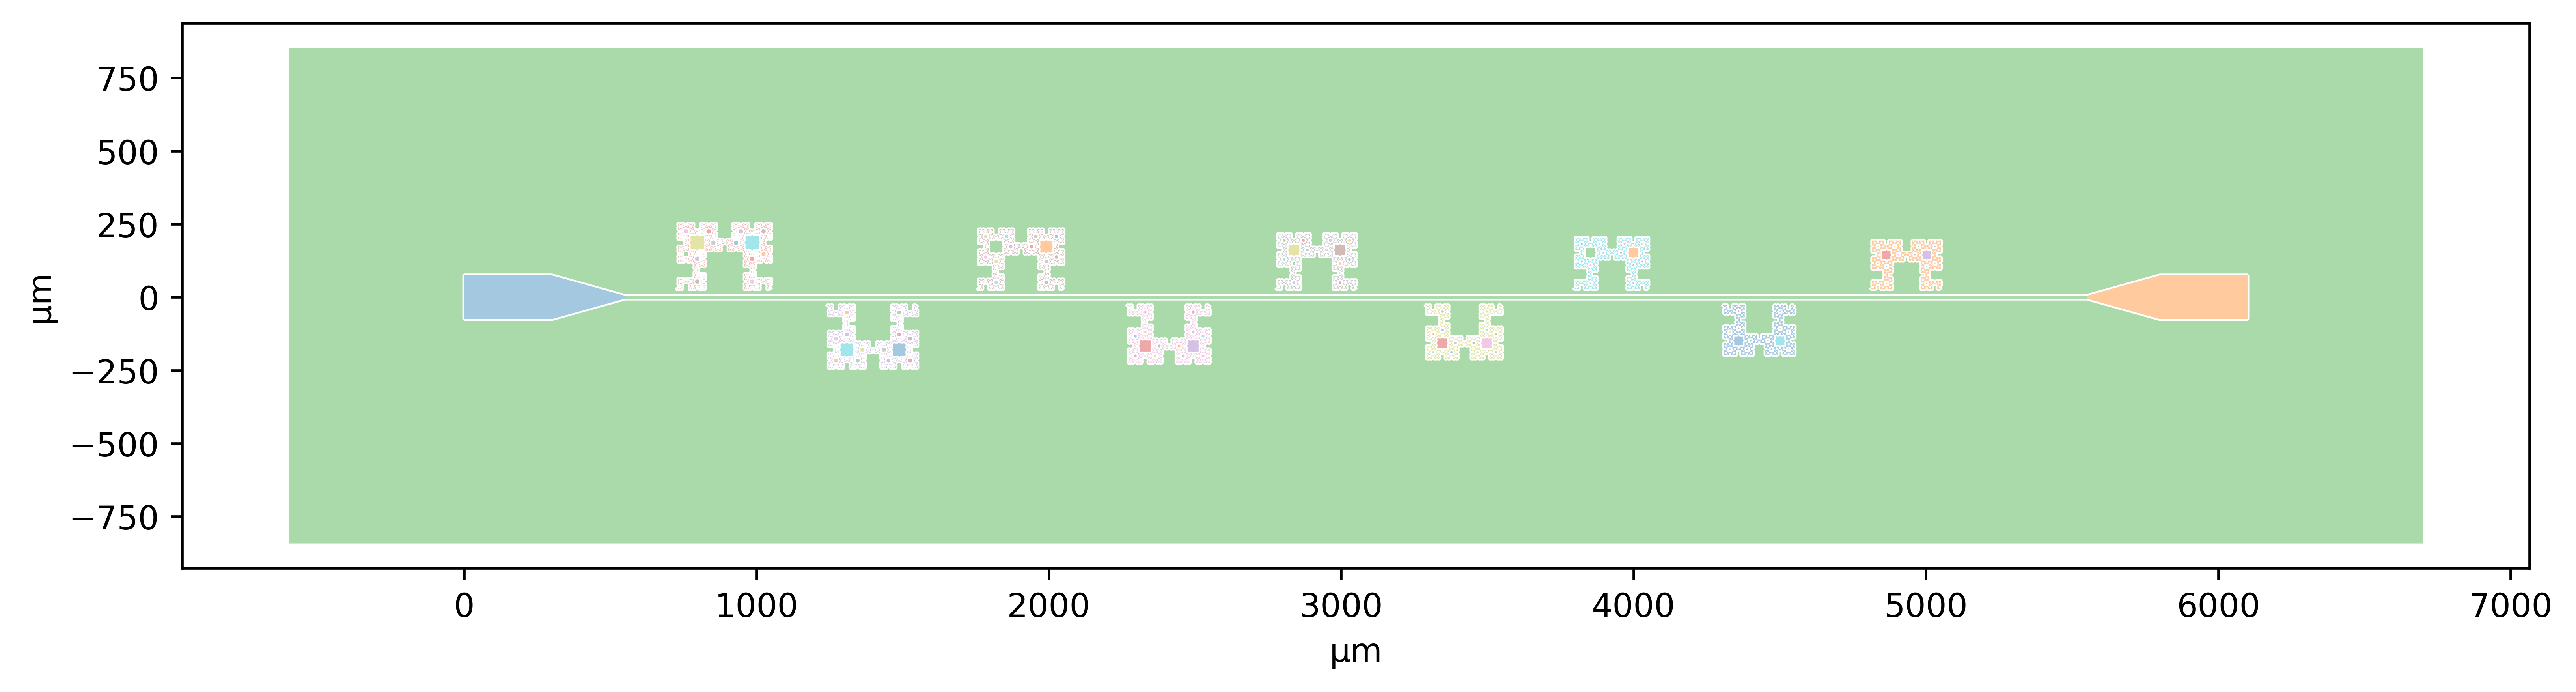


OASIS written to cpw_fibonacci_resonators_v001_calib.oas



In [145]:
#2)
#!/usr/bin/env python3
"""
CPW Feed with Rotated Fibonacci–Fractal λ/4 Metamaterial Resonators
(no IDCs) — v15 • Empirically‑calibrated λ/4 reference

Author   : Onri Jay Benally
Date     : 2025‑06‑19
───────────────────────────────────────────
This variant aligns the layout with Monte‑Carlo by using the
same empirical λ/4 reference length (5 280 µm @ 5 GHz).

Key deltas
─────────────────────
1. **LQ_REF_5GHZ = 5 280 µm**  (0.88× geometric round‑trip)
2. Applies kinetic‑inductance shortening λ′/4 = λ/4 /√(1+L_k/L_g).

Effect
──────
Expect R0 ≈ 5.0 GHz and R8 ≈ 8.0 GHz in the Monte‑Carlo sweep.
"""
import math, warnings
from typing import List, Tuple
import gdstk, numpy as np
from scipy.constants import mu_0
import matplotlib.pyplot as plt; import matplotlib as mpl
mpl.rcParams["figure.dpi"] = 600

# ───────────────────────────── 1)  Knobs ─
FIB_ITER, NUM_RESONATORS = 15, 9
FREQ_MIN, FREQ_MAX = 5.0, 8.0          # GHz design band
LQ_REF_5GHZ = 5280.0                   # µm λ/4 @5 GHz (empirical 0.88×)

W_RES_MIN, W_RES_MAX = 1.0, 3.0        # µm width ramp
GAP_RES = 6.0                          # µm CPW gap

USE_LK, MATERIAL = True, "Nb"
FILM_T_NM, LAMBDA_L0_NM = 80.0, 90.0

# tech dictionary (unchanged)
tech=dict(w_feed=10.0,g_feed=6.0,feed_len=None,w_res=1.0,
          fractal_spacing=20.0,fractal_horz_spacing=500.0,
          pad_len=300.0,pad_wid=150.0,pad_taper_len=250.0,
          sq_margin=50.0,fillet_radius=25.0,g_res=6.0,margin=600.0)
tech["g_max"]=max(tech["g_feed"],tech["g_res"])

FILLET_MIN,FILLET_MAX=0.2,0.6

# Fibonacci word
_DIRECTIONS=np.array([[1,0],[0,1],[-1,0],[0,-1]])

def fib_word(n:int)->str:
    a,b="0","01"
    for _ in range(n-1): a,b=b,b+a
    return b
_WORD=fib_word(FIB_ITER)
_NUM_MOVES=len(_WORD); _NUM_TURNS=_WORD.count("0")
_unit=[np.array([0.,0.])]; cur=0
for idx,ch in enumerate(_WORD):
    if ch=="1": _unit.append(_unit[-1]+_DIRECTIONS[cur])
    else:
        cur=(cur+(1 if idx%2==0 else -1))%4
        _unit.append(_unit[-1]+_DIRECTIONS[cur])
_unit=np.asarray(_unit)

# helpers
rotate90=lambda pts: np.column_stack((-pts[:,1],pts[:,0]))
rect=lambda x0,y0,x1,y1: gdstk.rectangle((x0,y0),(x1,y1))

def preview(cell,figsize=(11,4)):
    fig,ax=plt.subplots(figsize=figsize)
    if hasattr(cell,"plot"): cell.plot(ax)
    else:
        for p in cell.polygons: ax.fill(p.points[:,0],p.points[:,1],alpha=0.4,lw=0.3)
    ax.set_aspect('equal'); ax.set_xlabel('µm'); ax.set_ylabel('µm'); plt.tight_layout(); plt.show()

# electrical helpers
lambda_q=lambda f: LQ_REF_5GHZ*FREQ_MIN/f  # µm prior to kin‑L corr
choose_w=lambda f: W_RES_MIN+(W_RES_MAX-W_RES_MIN)*(f-FREQ_MIN)/(FREQ_MAX-FREQ_MIN)
choose_fil=lambda f: FILLET_MIN+(FILLET_MAX-FILLET_MIN)*(f-FREQ_MIN)/(FREQ_MAX-FREQ_MIN)

def lk_frac(w_um):
    if not USE_LK: return 0.0
    t=80e-9 if MATERIAL.lower()=="nb" else FILM_T_NM*1e-9
    lam=90e-9 if MATERIAL.lower()=="nb" else LAMBDA_L0_NM*1e-9
    w=w_um*1e-6
    Lk=mu_0*lam**2/(w*t)
    k=w/(w+2*GAP_RES*1e-6)
    import mpmath as mp
    Lg=(mu_0/4)*mp.ellipk(1-k**2)/mp.ellipk(k**2)
    return float(Lk/Lg)

def step_len(lq_um,fil,lk):
    lq_eff=lq_um/math.sqrt(1+lk)
    k=(2-math.pi/2)
    return lq_eff/(_NUM_MOVES-_NUM_TURNS*fil*k)

# resonator builder

def build_res(origin,freq,up):
    w=choose_w(freq); fil=choose_fil(freq); lk=lk_frac(w)
    step=step_len(lambda_q(freq),fil,lk)
    pts=rotate90(_unit*step)
    if not up: pts=pts.copy(); pts[:,1]*=-1
    pts+=np.asarray(origin)-pts[0]
    fp=gdstk.FlexPath(pts.tolist(),w,bend_radius=fil*step,simple_path=True)
    return fp.to_polygons()

# chip assembly

def build_chip(p):
    lib=gdstk.Library(unit=1e-6); cell=lib.new_cell('MAIN')
    conductors=[]
    pitch=p['fractal_horz_spacing']; p['feed_len']=(NUM_RESONATORS-1)*pitch+2*pitch
    feed_x0=p['pad_len']+p['pad_taper_len']
    def launch(x,dir):
        w1,w2=p['w_feed'],p['pad_wid']; xt=x+dir*p['pad_taper_len']; xp=xt+dir*p['pad_len']
        return gdstk.Polygon([(x,w1/2),(xt,w2/2),(xp,w2/2),(xp,-w2/2),(xt,-w2/2),(x,-w1/2)])
    cell.add(launch(feed_x0,-1),launch(feed_x0+p['feed_len'],1))
    feed=rect(feed_x0,-p['w_feed']/2,feed_x0+p['feed_len'],p['w_feed']/2); cell.add(feed)
    conductors.extend(cell.polygons)
    start_x=feed_x0+pitch; freqs=np.linspace(FREQ_MIN,FREQ_MAX,NUM_RESONATORS)
    for i,f in enumerate(freqs):
        x=start_x+i*pitch; y_off=p['w_feed']/2+p['g_feed']+p['fractal_spacing']
        y=y_off if i%2==0 else -y_off
        polys=build_res((x,y),f,i%2==0); cell.add(*polys); conductors.extend(polys)
    cu=gdstk.boolean(conductors,[],"or"); xs=np.concatenate([p.points[:,0] for p in cu]); ys=np.concatenate([p.points[:,1] for p in cu])
    frame=rect(xs.min()-p['margin'],ys.min()-p['margin'],xs.max()+p['margin'],ys.max()+p['margin'])
    keep=gdstk.offset(cu,p['g_max']+0.1,join='round') or []
    try: ground=gdstk.boolean(frame,keep,'not') if keep else [frame]
    except: ground=[frame]
    cell.add(*ground)
    return lib

if __name__=='__main__':
    warnings.filterwarnings('ignore',category=RuntimeWarning)
    lib=build_chip(tech); preview(lib.top_level()[0])
    lib.write_oas('cpw_fibonacci_resonators_v001_calib.oas')
    print('\nOASIS written to cpw_fibonacci_resonators_v001_calib.oas\n')

In [146]:
# 4) CPU-based Monte Carlo Resonance Frequency Prediction
import numpy as np
import pandas as pd
from IPython.display import display

# — ensure your f0 samples live on the CPU as a NumPy array —
#   if you’d accidentally generated them on GPU via CuPy, this brings them back
f0_np = f0.get() if hasattr(f0, 'get') else np.asarray(f0)
# f0_np shape: (n_trials, n_resonators)

# — compute per-resonator statistics (Hz) —
mean_f0 = np.mean( f0_np, axis=0 )
std_f0  = np.std(  f0_np, axis=0 )
min_f0  = np.min(  f0_np, axis=0 )
max_f0  = np.max(  f0_np, axis=0 )

# — convert to GHz for reporting —
mean_GHz = mean_f0 / 1e9
std_GHz  = std_f0  / 1e9
min_GHz  = min_f0  / 1e9
max_GHz  = max_f0  / 1e9

# — assemble into a pandas DataFrame —
resonator_labels = [f'R{n}' for n in range(len(mean_GHz))]
stats_df = pd.DataFrame({
    'Mean f₀ (GHz)': mean_GHz,
    'Std  f₀ (GHz)': std_GHz,
    'Min  f₀ (GHz)': min_GHz,
    'Max  f₀ (GHz)': max_GHz,
}, index=resonator_labels)

print("▸ Predicted resonance frequency statistics per resonator:")
display(stats_df)

# — overall predicted range in GHz —
overall_min = min_GHz.min()
overall_max = max_GHz.max()
print(f"\n▸ Overall predicted resonance-frequency range: "
      f"{overall_min:.3f} GHz – {overall_max:.3f} GHz")

# — if loaded-Q (Q_L) exists, compute half-power bandwidth (MHz) —
if 'Q_L' in globals():
    QL = Q_L.get() if hasattr(Q_L, 'get') else Q_L
    # bandwidth = f₀ / Q_loaded (Hz) → MHz
    bw_Hz  = mean_f0 / QL
    bw_MHz = bw_Hz  / 1e6
    stats_df['BW (MHz)'] = bw_MHz

    print("\n▸ Loaded-Q–based half-power bandwidth per resonator (MHz):")
    display(stats_df[['BW (MHz)']])

▸ Predicted resonance frequency statistics per resonator:


,Mean f₀ (GHz),Std f₀ (GHz),Min f₀ (GHz),Max f₀ (GHz)
R0,4.979672,0.060122,4.707660,5.251323
R1,5.375166,0.064831,5.090054,5.648953
R2,5.760446,0.069629,5.478003,6.095980
R3,6.138987,0.074294,5.816982,6.455460
R4,6.512925,0.078729,6.190873,6.860739
R5,6.882918,0.083567,6.512502,7.236667
R6,7.250291,0.088135,6.851083,7.622764
R7,7.615657,0.092330,7.231330,8.011526
R8,7.978564,0.096820,7.590869,8.411205



▸ Overall predicted resonance-frequency range: 4.708 GHz – 8.411 GHz

▸ Loaded-Q–based half-power bandwidth per resonator (MHz):


,BW (MHz)
R0,0.034858
R1,0.037626
R2,0.040323
R3,0.042973
R4,0.045590
R5,0.048180
R6,0.050752
R7,0.053310
R8,0.055850


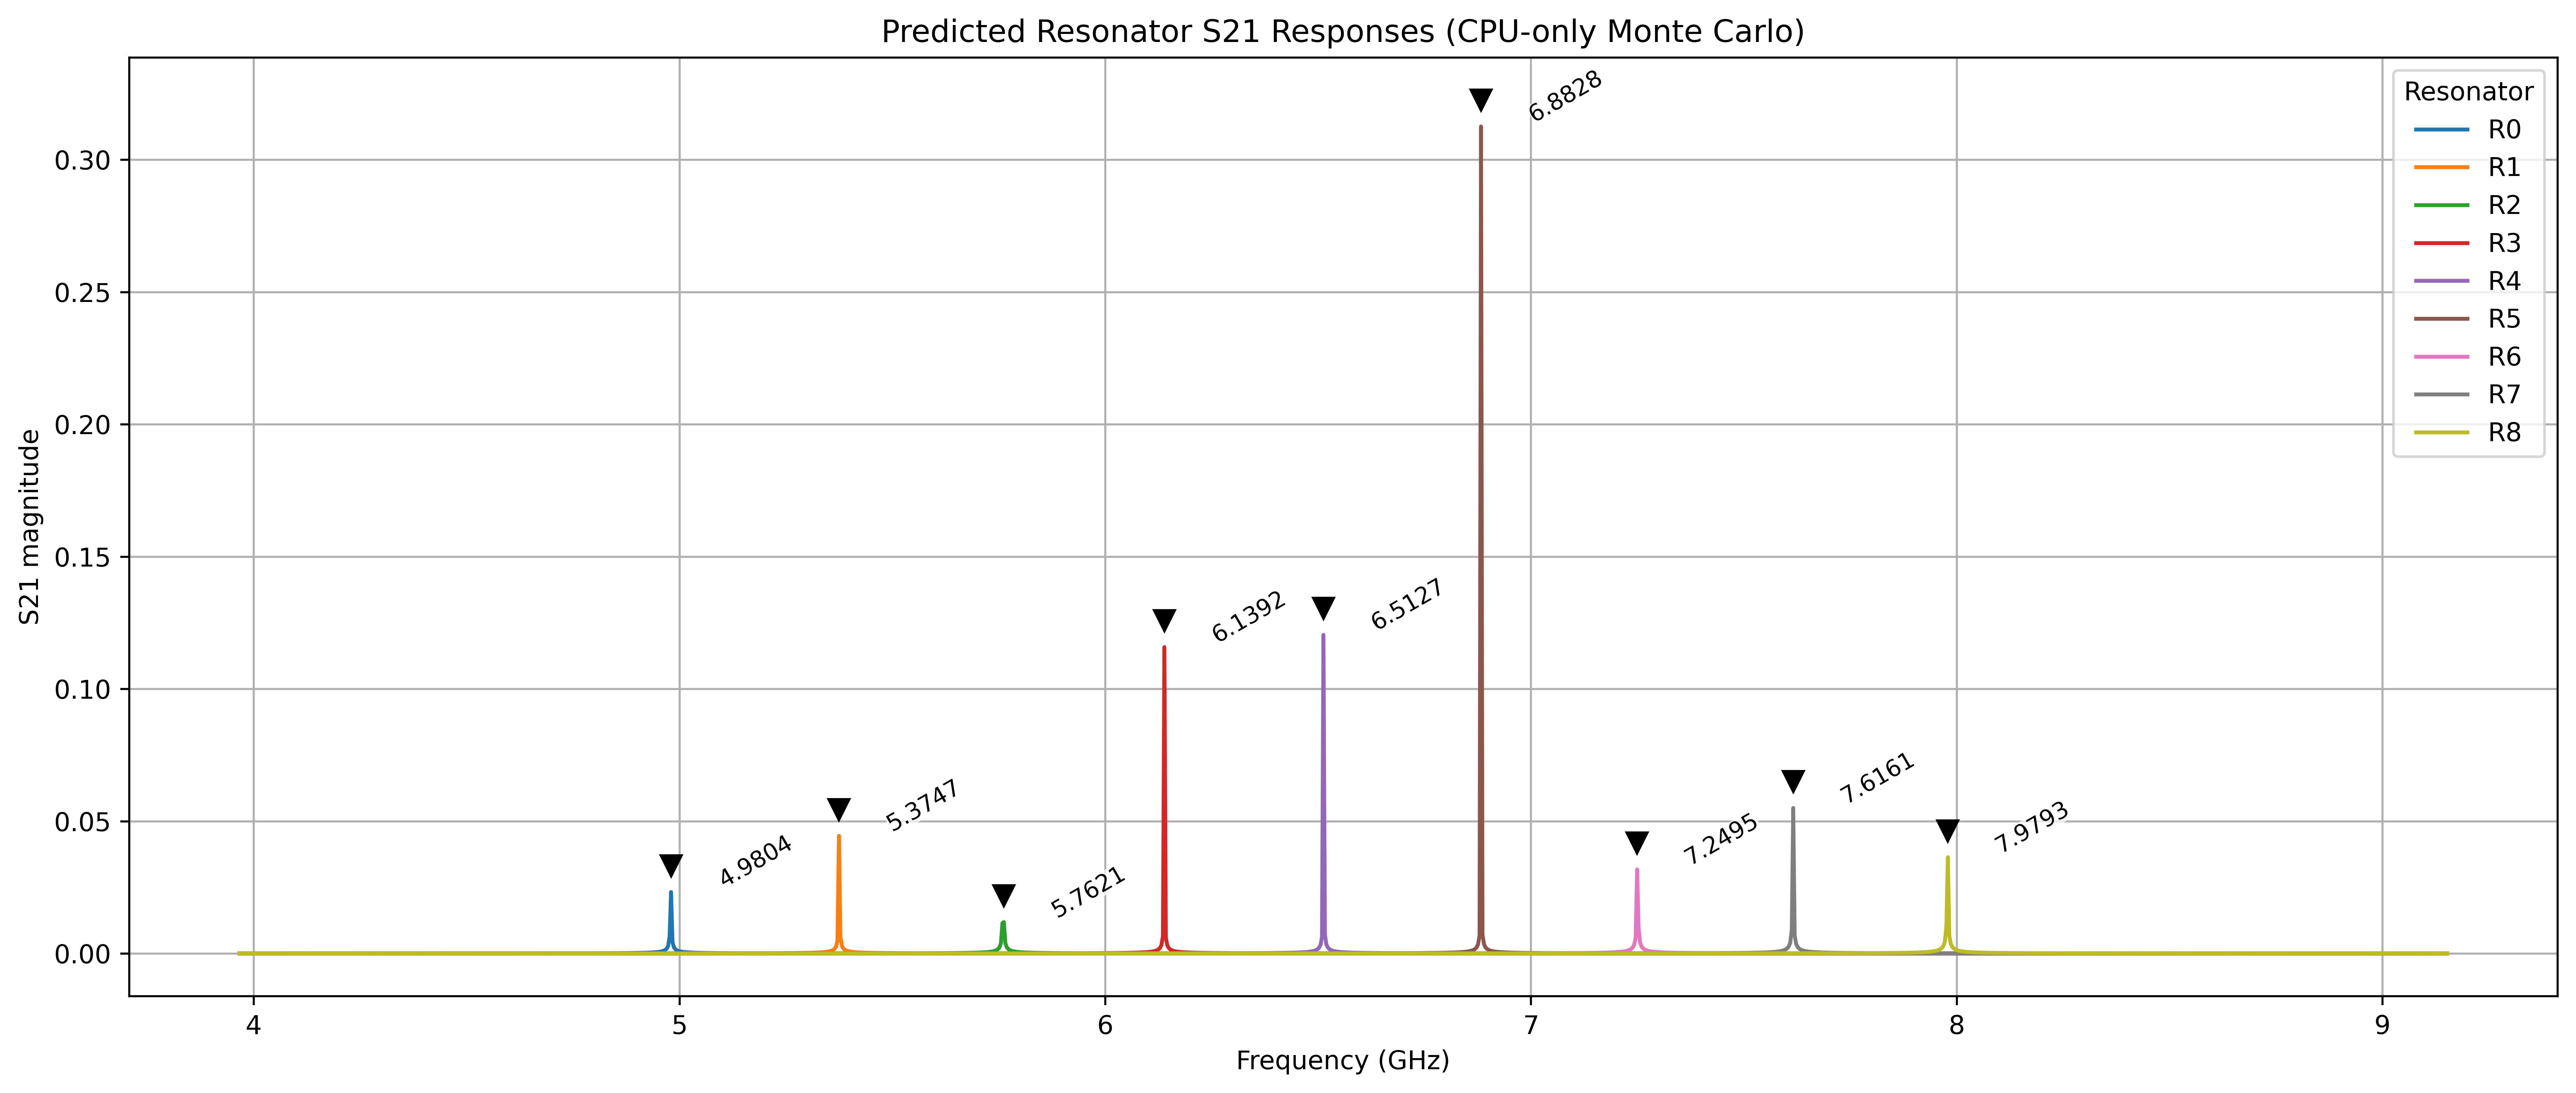

In [147]:
# 4) CPU-based Plot of Predicted S21 Resonance Responses via Monte Carlo
import numpy as np
import matplotlib.pyplot as plt

try:
    # 1) Grab loaded-Q on the CPU
    QL = Q_L.get() if hasattr(Q_L, 'get') else Q_L

    # 2) Build a frequency sweep (GHz ↔ Hz)
    margin      = 0.2  # 20% margin on each side
    span        = overall_max - overall_min
    f_min       = overall_min - span * margin
    f_max       = overall_max + span * margin
    f_sweep_GHz = np.linspace(f_min, f_max, 1500)
    f_sweep_Hz  = f_sweep_GHz * 1e9

    # 3) Prepare the plot
    fig, ax   = plt.subplots(figsize=(14, 6))
    span_plot = f_max - f_min

    # 4) Loop over each resonator
    for idx, f0_hz in enumerate(mean_f0):
        # determine per-resonator Q
        QL_i = QL[idx] if hasattr(QL, '__iter__') else QL

        # compute S21 magnitude (vectorized)
        S21_mag = 1 / np.sqrt(
            1 + 4 * (QL_i**2) * (((f_sweep_Hz - f0_hz) / f0_hz)**2)
        )
        ax.plot(f_sweep_GHz, S21_mag, label=f'R{idx}')

        # find and annotate the resonance peak
        idx_peak      = np.argmin(np.abs(f_sweep_Hz - f0_hz))
        peak_freq_GHz = f_sweep_GHz[idx_peak]
        peak_mag      = S21_mag[idx_peak]

        # triangle marker just above the peak
        ax.plot(peak_freq_GHz, peak_mag + 0.01,
                marker='v', markersize=8, color='black')

        # angled text label at 30° to the right
        offset_x = span_plot * 0.02
        ax.text(
            peak_freq_GHz + offset_x, peak_mag,
            f"{peak_freq_GHz:.4f}",
            fontsize=9, rotation=30,
            va='bottom', ha='left',
            bbox=dict(facecolor='white', edgecolor='none',
                      pad=0, alpha=0.7)
        )

    # 5) Finalize axes
    ax.set_xlabel('Frequency (GHz)')
    ax.set_ylabel('S21 magnitude')
    ax.set_title('Predicted Resonator S21 Responses (CPU-only Monte Carlo)')
    ax.legend(title='Resonator', loc='upper right')
    ax.grid(True)
    plt.tight_layout()
    plt.show()

except NameError:
    print("Loaded Q (Q_L) not defined; cannot plot S21 responses.")

In [148]:
# 4) GPU-Accelerated Resonance Frequency Prediction via Monte Carlo with CuPy
# — install CuPy for CUDA 11.x on Colab if you haven’t already:
#     !pip install cupy-cuda11x

import cupy as cp
import numpy as np
import pandas as pd
from IPython.display import display

# — make sure f0 is a CuPy array on the GPU —
f0_cp = f0 if isinstance(f0, cp.ndarray) else cp.asarray(f0)

# — compute per-resonator statistics on GPU (Hz) —
mean_f0_cp = cp.mean(f0_cp, axis=0)
std_f0_cp  = cp.std( f0_cp, axis=0)
min_f0_cp  = cp.min( f0_cp, axis=0)
max_f0_cp  = cp.max( f0_cp, axis=0)

# — convert to GHz on GPU —
mean_GHz_cp = mean_f0_cp / 1e9
std_GHz_cp  = std_f0_cp  / 1e9
min_GHz_cp  = min_f0_cp  / 1e9
max_GHz_cp  = max_f0_cp  / 1e9

# — bring just the stats you need back to host for pandas —
mean_GHz = cp.asnumpy(mean_GHz_cp)
std_GHz  = cp.asnumpy(std_GHz_cp )
min_GHz  = cp.asnumpy(min_GHz_cp )
max_GHz  = cp.asnumpy(max_GHz_cp )

# — build the DataFrame —
resonator_labels = [f"R{n}" for n in range(len(mean_GHz))]
stats_df = pd.DataFrame({
    "Mean f₀ (GHz)": mean_GHz,
    "Std  f₀ (GHz)": std_GHz,
    "Min  f₀ (GHz)": min_GHz,
    "Max  f₀ (GHz)": max_GHz,
}, index=resonator_labels)

print("▸ Predicted resonance frequency statistics per resonator:")
display(stats_df)

# — overall predicted range —
overall_min = min_GHz.min()
overall_max = max_GHz.max()
print(f"\n▸ Overall predicted resonance-frequency range: "
      f"{overall_min:.3f} GHz – {overall_max:.3f} GHz")

# — if loaded-Q (Q_L) is defined, compute half-power bandwidth —
if "Q_L" in globals():
    QL_cp = Q_L if isinstance(Q_L, cp.ndarray) else cp.asarray(Q_L)
    bw_Hz_cp  = mean_f0_cp / QL_cp
    bw_MHz_cp = bw_Hz_cp / 1e6
    bw_MHz    = cp.asnumpy(bw_MHz_cp)

    stats_df["BW (MHz)"] = bw_MHz
    print("\n▸ Loaded-Q–based half-power bandwidth per resonator (MHz):")
    display(stats_df[["BW (MHz)"]])

▸ Predicted resonance frequency statistics per resonator:


,Mean f₀ (GHz),Std f₀ (GHz),Min f₀ (GHz),Max f₀ (GHz)
R0,4.979644,0.060122,4.707660,5.251323
R1,5.375175,0.064832,5.090054,5.648953
R2,5.760440,0.069629,5.478003,6.095980
R3,6.138992,0.074295,5.816982,6.455460
R4,6.512947,0.078729,6.190873,6.860739
R5,6.882928,0.083567,6.512502,7.236667
R6,7.250303,0.088135,6.851083,7.622764
R7,7.615653,0.092331,7.231330,8.011526
R8,7.978545,0.096821,7.590869,8.411205



▸ Overall predicted resonance-frequency range: 4.708 GHz – 8.411 GHz

▸ Loaded-Q–based half-power bandwidth per resonator (MHz):


,BW (MHz)
R0,0.034858
R1,0.037626
R2,0.040323
R3,0.042973
R4,0.045591
R5,0.048180
R6,0.050752
R7,0.053310
R8,0.055850


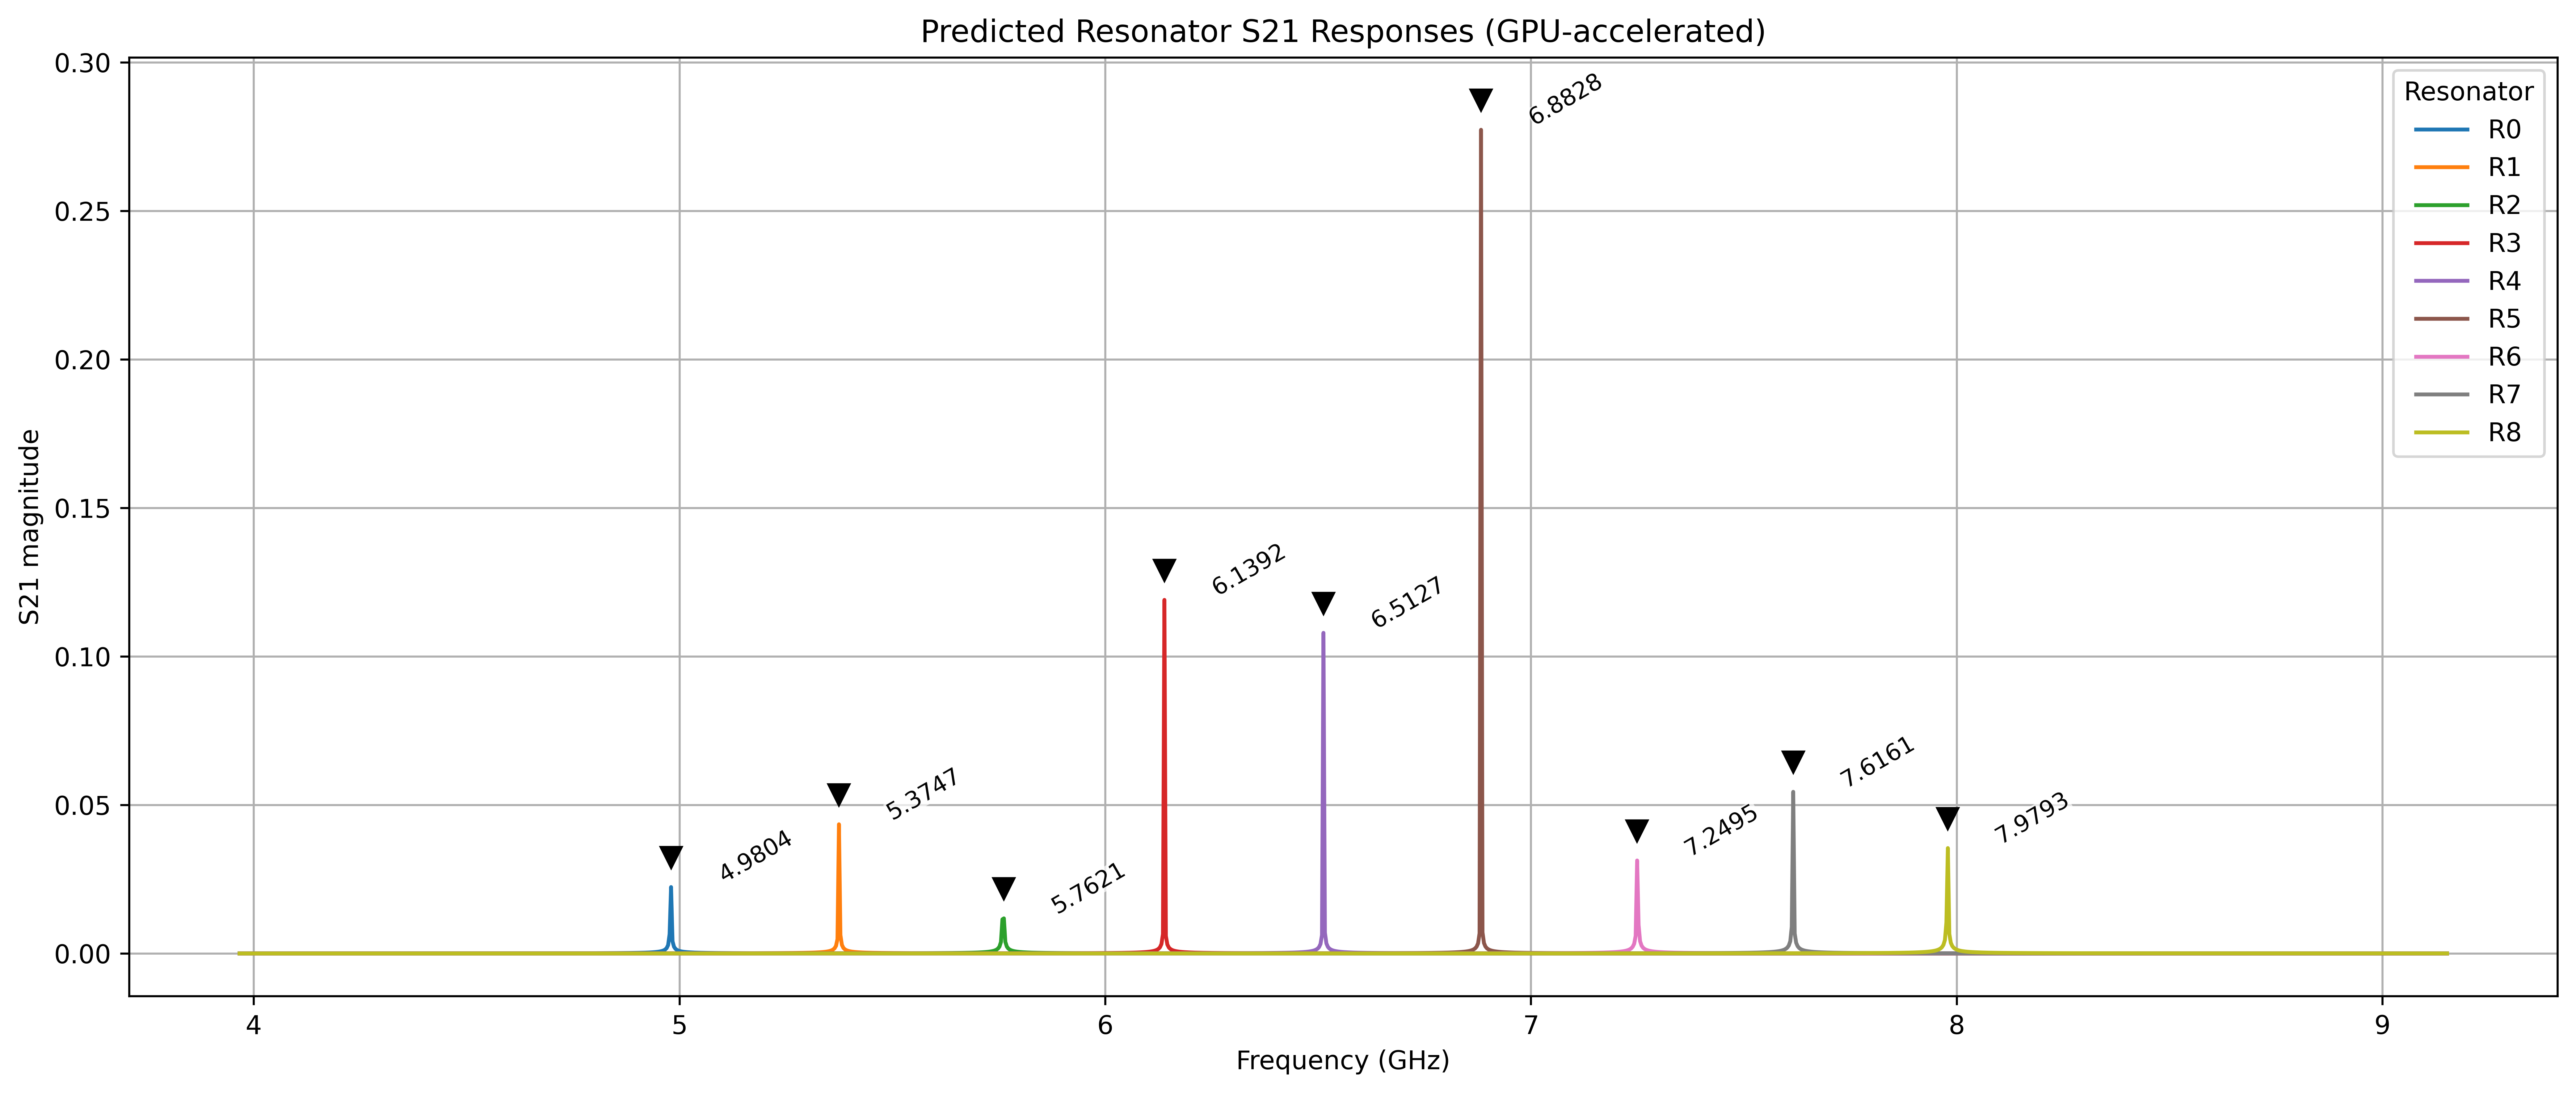

In [149]:
# 4) GPU-Accelerated Plot of Predicted S21 Resonance Responses via Monte Carlo with CuPy
# — make sure you have CuPy installed (e.g. pip install cupy-cuda11x)

import cupy as cp
import numpy as np
import matplotlib.pyplot as plt

try:
    # — 1) Grab loaded-Q on the CPU, then mirror to the GPU —
    QL_val = Q_L.get() if hasattr(Q_L, 'get') else Q_L
    # we'll need its length once we know how many resonators we have

    # — 2) Compute the mean resonance frequencies on the GPU (Hz) —
    f0_cp       = f0 if isinstance(f0, cp.ndarray) else cp.asarray(f0)
    mean_f0_cp  = cp.mean(f0_cp, axis=0)
    mean_f0     = cp.asnumpy(mean_f0_cp)            # back to CPU for indexing/annotation
    n_res       = mean_f0.shape[0]

    # — 3) Create a CPU array of QL of matching length, and copy that to GPU —
    if np.ndim(QL_val) == 0:
        QL_cpu = np.full(n_res, QL_val)
    else:
        QL_cpu = np.array(QL_val)
    QL_cp = cp.asarray(QL_cpu)

    # — 4) Build the frequency sweep entirely on GPU (GHz → Hz) —
    margin         = 0.2                # 20% on each side
    span           = overall_max - overall_min  # in GHz (CPU floats)
    f_min          = overall_min - span * margin
    f_max          = overall_max + span * margin
    f_sweep_GHz_cp = cp.linspace(f_min, f_max, 1500)
    f_sweep_Hz_cp  = f_sweep_GHz_cp * 1e9

    # pull these back once for plotting & peak finding
    f_sweep_GHz = cp.asnumpy(f_sweep_GHz_cp)
    f_sweep_Hz  = f_sweep_GHz * 1e9

    # — 5) Plot & annotate —
    fig, ax = plt.subplots(figsize=(14, 6))
    span_plot = f_max - f_min

    for idx in range(n_res):
        # per-resonator Q and f0 on GPU
        QL_i     = QL_cp[idx]
        f0_i_cp  = mean_f0_cp[idx]

        # compute S21 magnitude on GPU, then transfer the result
        S21_cp   = 1 / cp.sqrt(
            1 + 4*(QL_i**2)*(((f_sweep_Hz_cp - f0_i_cp)/f0_i_cp)**2)
        )
        S21_mag  = cp.asnumpy(S21_cp)

        ax.plot(f_sweep_GHz, S21_mag, label=f'R{idx}')

        # find the resonance peak (on CPU)
        idx_peak      = np.argmin(np.abs(f_sweep_Hz - mean_f0[idx]))
        peak_freq_GHz = f_sweep_GHz[idx_peak]
        peak_mag      = S21_mag[idx_peak]

        # plot marker & angled label
        y_offset = 0.01
        ax.plot(peak_freq_GHz, peak_mag + y_offset,
                marker='v', markersize=8, color='k')
        offset_x = span_plot * 0.02
        ax.text(
            peak_freq_GHz + offset_x, peak_mag,
            f"{peak_freq_GHz:.4f}",
            fontsize=9, rotation=30,
            va='bottom', ha='left',
            bbox=dict(facecolor='white', edgecolor='none',
                      pad=0.0, alpha=0.7)
        )

    ax.set_xlabel('Frequency (GHz)')
    ax.set_ylabel('S21 magnitude')
    ax.set_title('Predicted Resonator S21 Responses (GPU-accelerated)')
    ax.legend(title='Resonator', loc='upper right')
    ax.grid(True)
    plt.tight_layout()
    plt.show()

except NameError:
    print("Loaded Q (Q_L) not defined; cannot plot S21 responses.")

In [150]:
#  Resonator Statistics – Fail‑proof single cell (ASCII‑only)
#  Paste this cell immediately after your simulation code.
#  If auto‑detection fails, set the override variables below.

# ---------- OPTIONAL MANUAL OVERRIDES -----------------------
FREQ_VAR      = None   # e.g. "freqs_GHz"       (1‑D array, Hz/GHz/MHz)
BANDWIDTH_VAR = None   # e.g. "bandwidths_MHz"  (1‑D array or scalar)
Q_VAR         = None   # e.g. "Q_loaded"        (1‑D array or scalar)

import numpy as np
import pandas as pd
import re
import numbers
from IPython.display import display

UNIT_SCALE = {"ghz": 1e9, "mhz": 1e6, "khz": 1e3}

# ---------- helper functions --------------------------------

def unit_scale(name: str) -> float:
    name = name.lower()
    for suf, scl in UNIT_SCALE.items():
        if suf in name:
            return scl
    return 1.0  # assume Hz


def to_1d(arr_like):
    """Convert any list/ndarray/CuPy/scalar to a 1‑D NumPy float array."""
    if isinstance(arr_like, numbers.Real):
        return np.asarray([arr_like], float)
    try:
        arr = np.asarray(arr_like, float)
    except Exception:
        arr = np.asarray(list(arr_like), float)
    return arr.ravel()


def safe_len(obj):
    try:
        return len(obj)
    except Exception:
        return 0

# ---------- 1) locate frequency array ------------------------
if FREQ_VAR:
    if FREQ_VAR not in globals():
        raise NameError(f"{FREQ_VAR!r} not defined in workspace.")
    freq_name = FREQ_VAR
    freq_arr = to_1d(globals()[FREQ_VAR])
else:
    freq_name = None
    freq_arr = None
    freq_pat = re.compile(r"f(0|req|r)|center.*f|res.*f", re.I)
    for name, obj in list(globals().items()):
        if freq_pat.search(name) and safe_len(obj):
            freq_name = name
            freq_arr = to_1d(obj)
            break
    if freq_arr is None:
        raise NameError("Could not detect a frequency array – set FREQ_VAR.")

f0_Hz = freq_arr * unit_scale(freq_name)
N = len(f0_Hz)

# ---------- 2) locate bandwidth OR loaded‑Q ------------------
bw_arr = None
q_arr = None
bw_name = None
q_name = None

# manual overrides first
if BANDWIDTH_VAR:
    if BANDWIDTH_VAR not in globals():
        raise NameError(f"{BANDWIDTH_VAR!r} not defined.")
    bw_name = BANDWIDTH_VAR
    bw_arr = to_1d(globals()[BANDWIDTH_VAR])

if Q_VAR and bw_arr is None:
    if Q_VAR not in globals():
        raise NameError(f"{Q_VAR!r} not defined.")
    q_name = Q_VAR
    q_arr = to_1d(globals()[Q_VAR])

# auto‑detect if still missing
if bw_arr is None and q_arr is None:
    bw_pat = re.compile(r"bw|bandwidth|deltaf|fwhm", re.I)
    q_pat = re.compile(r"(^q$|ql$|qvals|q_loaded|loadedq|q_l|qload)", re.I)
    for name, obj in list(globals().items()):
        if name == freq_name:
            continue
        L = safe_len(obj)
        if L not in (1, N):
            continue
        if bw_pat.search(name) and bw_arr is None:
            bw_name = name
            bw_arr = to_1d(obj)
        if q_pat.search(name) and q_arr is None:
            q_name = name
            q_arr = to_1d(obj)
        if bw_arr is not None or q_arr is not None:
            break

# broadcast scalars if necessary
if bw_arr is not None and len(bw_arr) == 1:
    bw_arr = np.repeat(bw_arr, N)
if q_arr is not None and len(q_arr) == 1:
    q_arr = np.repeat(q_arr, N)

if bw_arr is None and q_arr is None:
    cand = [n for n, o in globals().items() if safe_len(o) in (1, N)]
    raise NameError(
        "No bandwidth or Q array (1‑D or scalar) matches frequency length.\n" +
        "Candidate arrays: " + ", ".join(cand)
    )

# ---------- 3) compute / convert Q ---------------------------
if bw_arr is not None:
    bw_Hz = bw_arr * unit_scale(bw_name)
    q_loaded = f0_Hz / bw_Hz
else:
    bw_Hz = np.full_like(f0_Hz, np.nan)
    q_loaded = q_arr

# ---------- 4) build DataFrame & display ---------------------
res_data = pd.DataFrame({
    "f0_GHz": f0_Hz / 1e9,
    "bandwidth_Hz": bw_Hz,
    "Q_loaded": q_loaded,
})

print(
    f"[info] Frequency: '{freq_name}', " +
    (f"Bandwidth: '{bw_name}'" if bw_arr is not None else f"Q: '{q_name}'")
)

print("\n▸ Per‑resonator table:")
display(res_data)

print("▸ Aggregate statistics:")
agg = res_data[["f0_GHz", "bandwidth_Hz", "Q_loaded"]].agg(
    ["count", "mean", "std", "min", "max"]
).T
agg["mean ± σ"] = (
    agg["mean"].round(5).astype(str) + " ± " + agg["std"].round(5).astype(str)
)
display(agg[["count", "mean ± σ", "min", "max"]])

[info] Frequency: 'freqs', Q: 'Q_L_mean'

▸ Per‑resonator table:


,f0_GHz,bandwidth_Hz,Q_loaded
0,5.000000e-09,NaN,142710.421875
1,5.250000e-09,NaN,142787.484375
2,5.500000e-09,NaN,142754.187500
3,5.750000e-09,NaN,142802.859375
4,6.000000e-09,NaN,142769.046875
5,6.250000e-09,NaN,142767.875000
6,6.500000e-09,NaN,142763.859375
7,6.750000e-09,NaN,142771.421875
8,7.000000e-09,NaN,142760.484375


▸ Aggregate statistics:


,count,mean ± σ,min,max
f0_GHz,9.0,0.0 ± 0.0,5.000000e-09,7.000000e-09
bandwidth_Hz,0.0,nan ± nan,NaN,NaN
Q_loaded,9.0,142765.2934 ± 25.30159,1.427104e+05,1.428029e+05
